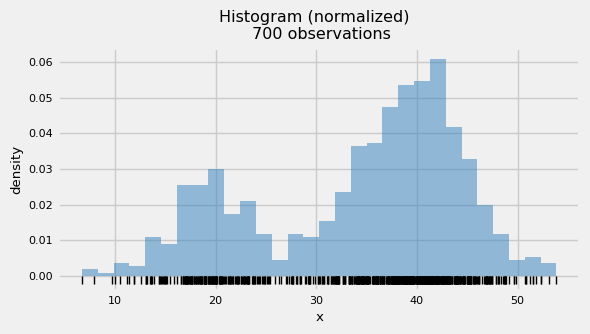

In [1]:
# Histogram example bimodal distribution
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8

sample_1 = np.random.normal(loc=20, scale=5, size=200)
sample_2 = np.random.normal(loc=40, scale=5, size=500)
data     = np.hstack((sample_1, sample_2))

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(data, bins=30, density=True, color="#3182bd", alpha=0.5)
ax.plot(data, np.full_like(data, -0.001), '|k', markeredgewidth=1)
ax.set_title('Histogram (normalized)  \n 700 observations')
ax.set_xlabel('x')
ax.set_ylabel('density');



In [2]:
# List of available styles
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

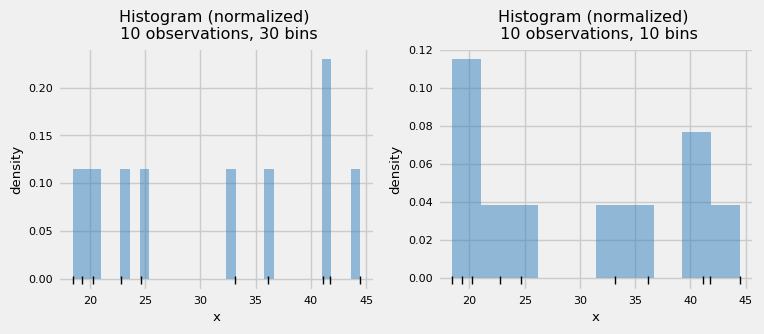

In [3]:
# Histogram example bimodal distribution with few observations
# ==============================================================================
sample_1 = np.random.normal(loc=20, scale=5, size=5)
sample_2 = np.random.normal(loc=40, scale=5, size=5)
data     = np.hstack((sample_1, sample_2))

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))
axs[0].hist(data, bins=30, density=True, color="#3182bd", alpha=0.5)
axs[0].plot(data, np.full_like(data, -0.001), '|k', markeredgewidth=1)
axs[0].set_title('Histogram (normalized) \n 10 observations, 30 bins')
axs[0].set_xlabel('x')
axs[0].set_ylabel('density');

axs[1].hist(data, bins=10, density=True, color="#3182bd", alpha=0.5)
axs[1].plot(data, np.full_like(data, -0.001), '|k', markeredgewidth=1)
axs[1].set_title('Histogram (normalized) \n 10 observations, 10 bins')
axs[1].set_xlabel('x')
axs[1].set_ylabel('density');


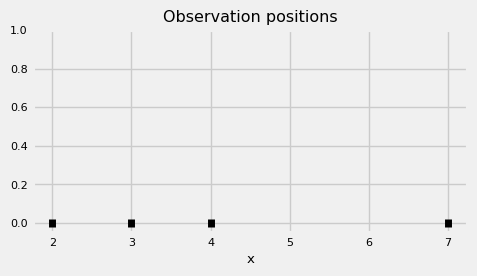

In [4]:
# Create 4 observations
# ======================================================================================
X = np.array([2, 3, 4, 7])
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(X, np.full_like(X, 0.05), '|k', markeredgewidth=5)
ax.set_ylim(-0.05, 1)
ax.set_title('Observation positions')
ax.set_xlabel('x')
ax.set_ylabel('');


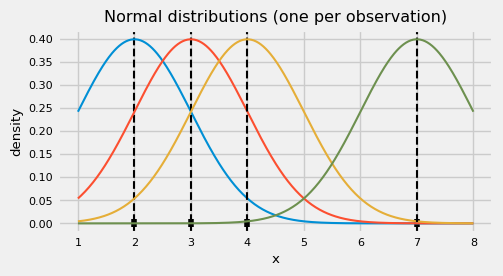

In [5]:
# Create normal distributions centered on each observation
# ======================================================================================
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(X, np.full_like(X, 0), '|k', markeredgewidth=4)

Xgrid = np.linspace(min(X) - 1, max(X) + 1, num=500)
for x in X:
    density = stats.norm.pdf(Xgrid, loc=x, scale=1)
    ax.axvline(x=x, linestyle='--', color='black')
    ax.plot(Xgrid, density)
    
ax.set_title('Normal distributions (one per observation)')
ax.set_xlabel('x')
ax.set_ylabel('density');


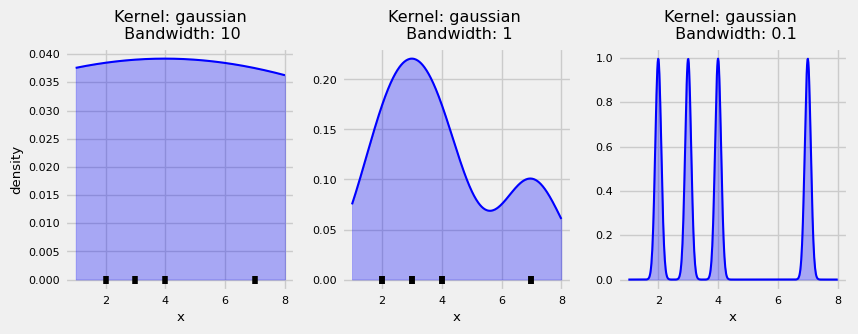

In [6]:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(9, 3))
X = np.array([2, 3, 4, 7])
Xgrid = np.linspace(min(X) - 1, max(X) + 1, num=500)

axs[0].plot(X, np.full_like(X, 0), '|k', markeredgewidth=4)
suma = np.full_like(Xgrid, 0)
for x in X:
    density = stats.norm.pdf(Xgrid, loc=x, scale=10)
    suma = suma + density
suma = suma / len(X)
axs[0].plot(Xgrid, suma, color='b')
axs[0].fill_between(Xgrid, suma, alpha=0.3, color='b')
axs[0].set_title('Kernel: gaussian\n Bandwidth: 10')
axs[0].set_xlabel('x')
axs[0].set_ylabel('density');

axs[1].plot(X, np.full_like(X, 0), '|k', markeredgewidth=4)
suma = np.full_like(Xgrid, 0)
for x in X:
    density = stats.norm.pdf(Xgrid, loc=x, scale=1)
    suma = suma + density 
suma = suma / len(X)
axs[1].plot(Xgrid, suma, color='b')
axs[1].fill_between(Xgrid, suma, alpha=0.3, color='b');
axs[1].set_title('Kernel: gaussian \n Bandwidth: 1')
axs[1].set_xlabel('x')

axs[1].plot(X, np.full_like(X, 0), '|k', markeredgewidth=4)
suma = np.full_like(Xgrid, 0)
for x in X:
    density = stats.norm.pdf(Xgrid, loc=x, scale=0.1)
    suma = suma + density 
suma = suma / len(X)
axs[2].plot(Xgrid, suma, color='b')
axs[2].fill_between(Xgrid, suma, alpha=0.3, color='b');
axs[2].set_title('Kernel: gaussian \n Bandwidth: 0.1')
axs[2].set_xlabel('x');


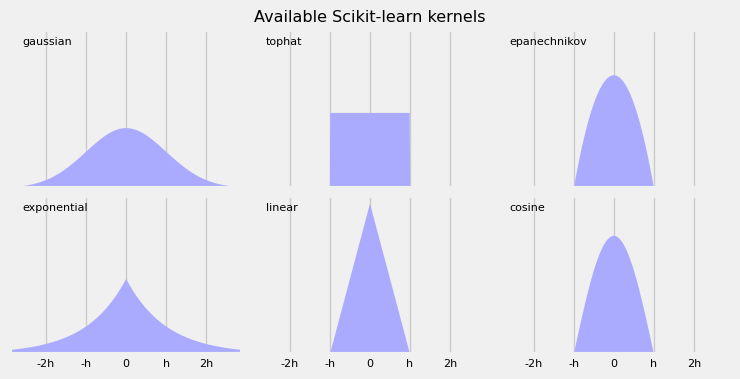

In [7]:
# Plots of available kernels (source: scikit-learn documentation)
# ----------------------------------------------------------------------
from sklearn.neighbors import KernelDensity
X_plot = np.linspace(-6, 6, 1000)[:, None]
X_src = np.zeros((1, 1))

fig, ax = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(8,4))
fig.subplots_adjust(left=0.05, right=0.95, hspace=0.05, wspace=0.05)

def format_func(x, loc):
    if x == 0:
        return '0'
    elif x == 1:
        return 'h'
    elif x == -1:
        return '-h'
    else:
        return '%ih' % x

for i, kernel in enumerate(['gaussian', 'tophat', 'epanechnikov',
                            'exponential', 'linear', 'cosine']):
    axi = ax.ravel()[i]
    log_dens = KernelDensity(kernel=kernel).fit(X_src).score_samples(X_plot)
    axi.fill(X_plot[:, 0], np.exp(log_dens), '-k', fc='#AAAAFF')
    axi.text(-2.6, 0.95, kernel)

    axi.xaxis.set_major_formatter(plt.FuncFormatter(format_func))
    axi.xaxis.set_major_locator(plt.MultipleLocator(1))
    axi.yaxis.set_major_locator(plt.NullLocator())

    axi.set_ylim(0, 1.05)
    axi.set_xlim(-2.9, 2.9)

ax[0, 1].set_title('Available Scikit-learn kernels');


In [8]:
# Data processing
# ==============================================================================
import pandas as pd
import numpy as np

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8

# Distribution fitting
# ==============================================================================
from scipy import stats
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# Warnings configuration
# ==============================================================================
import warnings
warnings.filterwarnings('once')


In [9]:
# Data
# ==============================================================================
n = 1000
np.random.seed(123)
sample_1 = np.random.normal(loc=1, scale=0.5, size=int(n * 0.75))
sample_2 = np.random.normal(loc=-1, scale=0.5, size=int(n * 0.25))
data = np.hstack((sample_1, sample_2))
